# Political Polling

Before we get started, let's install and load the packages and data we will be using today. I am also including a little bit of code that is optional, but will speed up installing packages *dramatically*.

In [1]:
options(repos = c(CRAN = "https://packagemanager.posit.co/cran/latest"))
install.packages("tidyverse")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [3]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Today, we are going to use what we've previously learned about data visualization with `ggplot2` and data wrangling with `dplyr` to analyze political polls. Specifically, we will:
1) Use `dplyr` verbs to calculate the results of poll questions for the whole survey (known as toplines) or for subgroups (known as crosstabs) while applying survey weights.
2) Use `ggplot2` to visualize the results of these polls, showing the margin of error alongside our poll results.

To do this, we are going to use data from the 2024 American National Election Study. The ANES is a large, nationally representative survey that collects data on voting behavior, political attitudes, and demographic characteristics of the U.S. population. This is the data from the pre-election questionnaires only.

This data dictionary describes the variables in the cleaned dataset.

|Variable Name|Description|
|:---|:---|
|`id`|A unique identifier for each respondent in the 2024 ANES Time Series study.|
|`party_id`|Respondent's 7-point party identification.|
|`race`|Respondent's self-identified race and ethnicity.|
|`age`|Respondent's age in years on Election Day.|
|`educ`|Respondent's highest level of education.|
|`gender`|Respondent's self-identified gender.|
|`income`|Respondent's total household income over the past 12 months, converted to the numeric midpoint of the original category.|
|`pres_vote`|A summary of the respondent's presidential vote choice or intent to vote from the pre-election survey.|
|`economy`|Respondent's approval or disapproval of how the president is handling the economy.|
|`immigration`|Respondent's approval or disapproval of the president's handling of immigration.|
|`crime`|Respondent's approval or disapproval of the president's handling of crime.|
|`attention_to_politics`|How often the respondent pays attention to government and politics.|
|`weights`|Survey weights to make the data nationally representative.|

You can load the data I've provided to you.

In [5]:
anes <- read_csv("anes_2024.csv")

Rows: 2171 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (9): attention_to_politics, pres_vote, economy, immigration, crime, part...
dbl (4): id, weights, age, income

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Survey Weights

Let's begin by doing a little exploratory data analysis on the survey weights used in this poll. What does the distribution of weights look like?

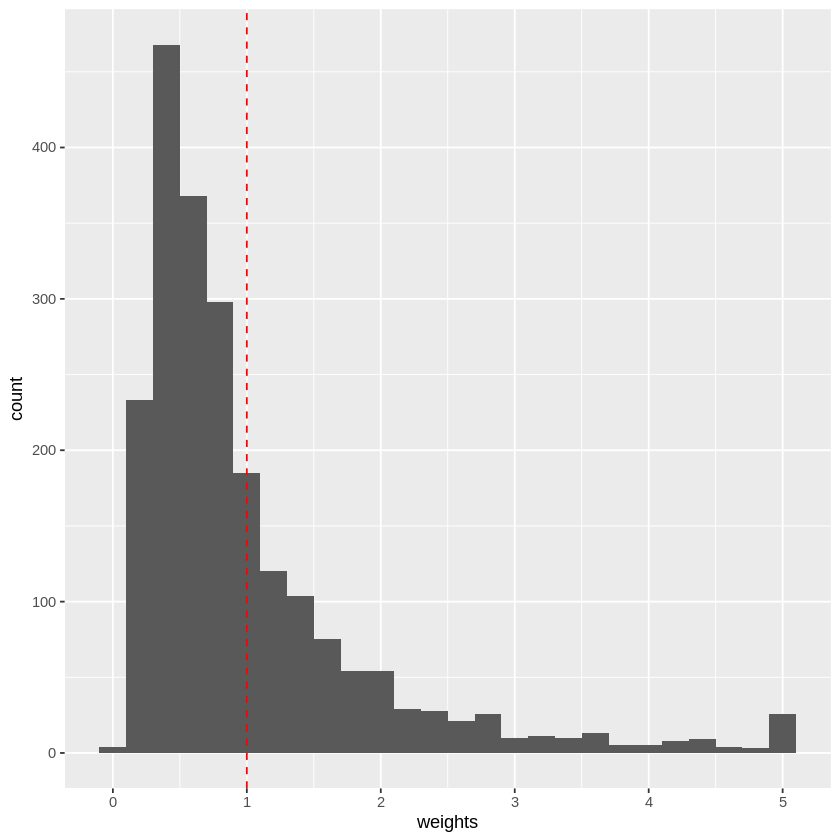

In [6]:
ggplot(anes) +
  geom_histogram(aes(x = weights), binwidth = .2) +
  geom_vline(xintercept = 1, color = "red", linetype = "dashed")

Warning message in geom_point(aes(x = age, y = weights), outliers = FALSE):
“Ignoring unknown parameters: `outliers`”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 103 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 103 rows containing missing values or values outside the scale range
(`geom_point()`).”


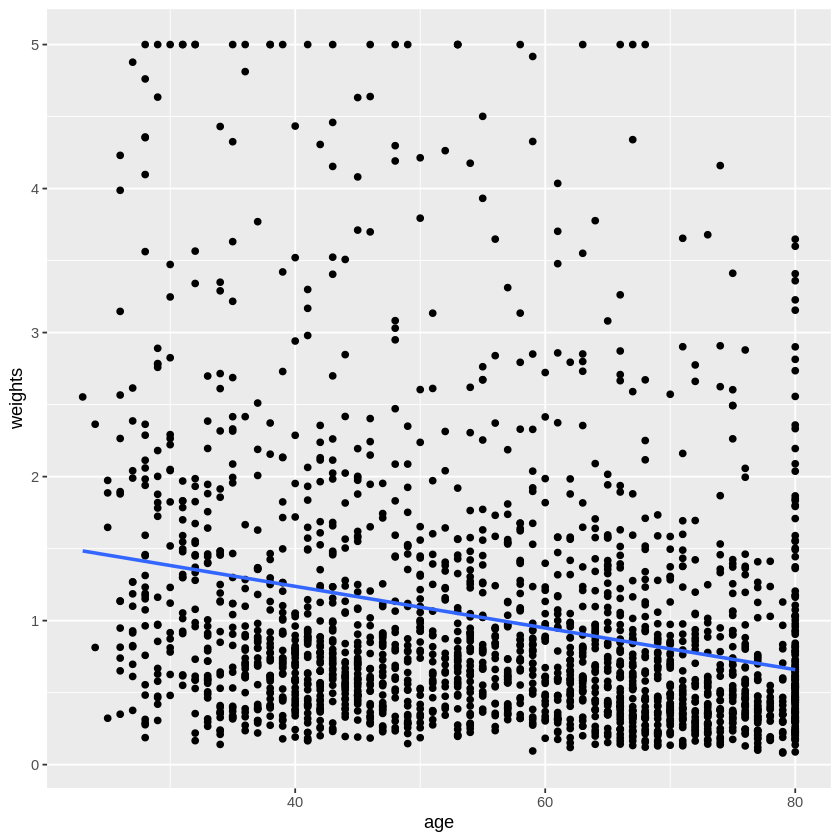

In [7]:
ggplot(anes) +
  geom_point(aes(x = age, y = weights), outliers = FALSE) +
  geom_smooth(aes(x = age, y = weights), method = "lm", se = FALSE)

Warning message in geom_point(aes(x = income, y = weights), outliers = FALSE):
“Ignoring unknown parameters: `outliers`”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 118 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 118 rows containing missing values or values outside the scale range
(`geom_point()`).”


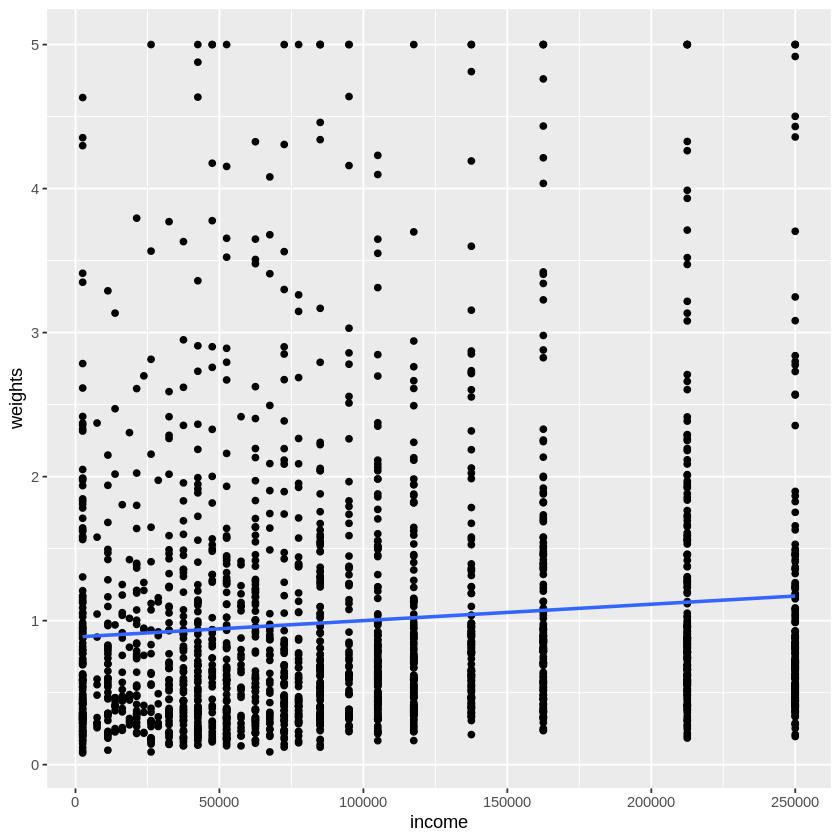

In [8]:
ggplot(anes) +
  geom_point(aes(x = income, y = weights), outliers = FALSE) +
  geom_smooth(aes(x = income, y = weights), method = "lm", se = FALSE)

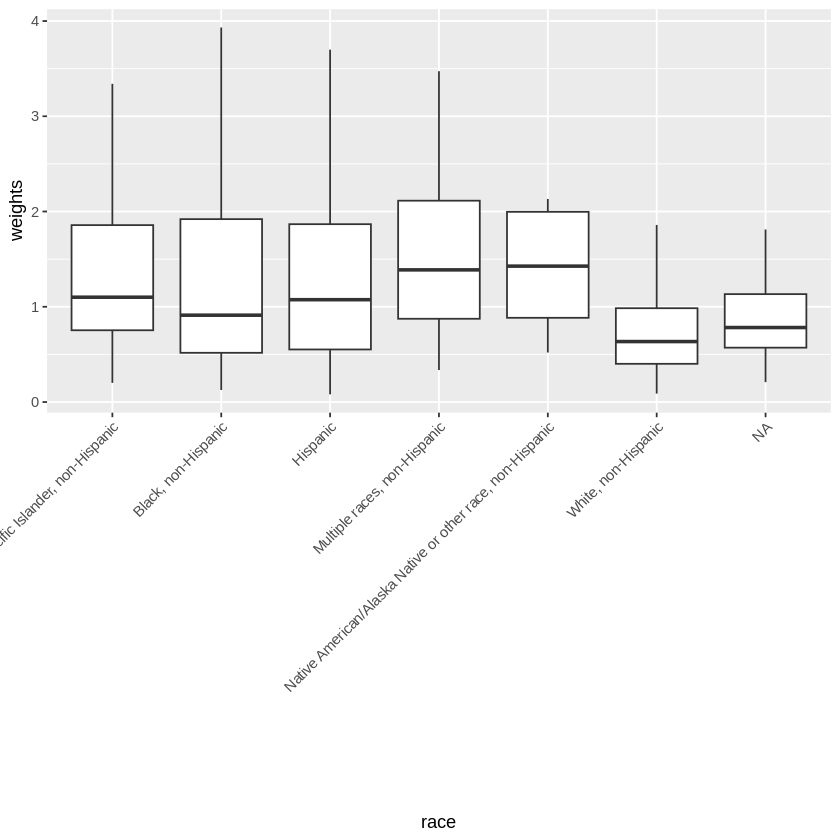

In [9]:
ggplot(anes) +
  geom_boxplot(aes(x = race, y = weights), outliers = FALSE) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

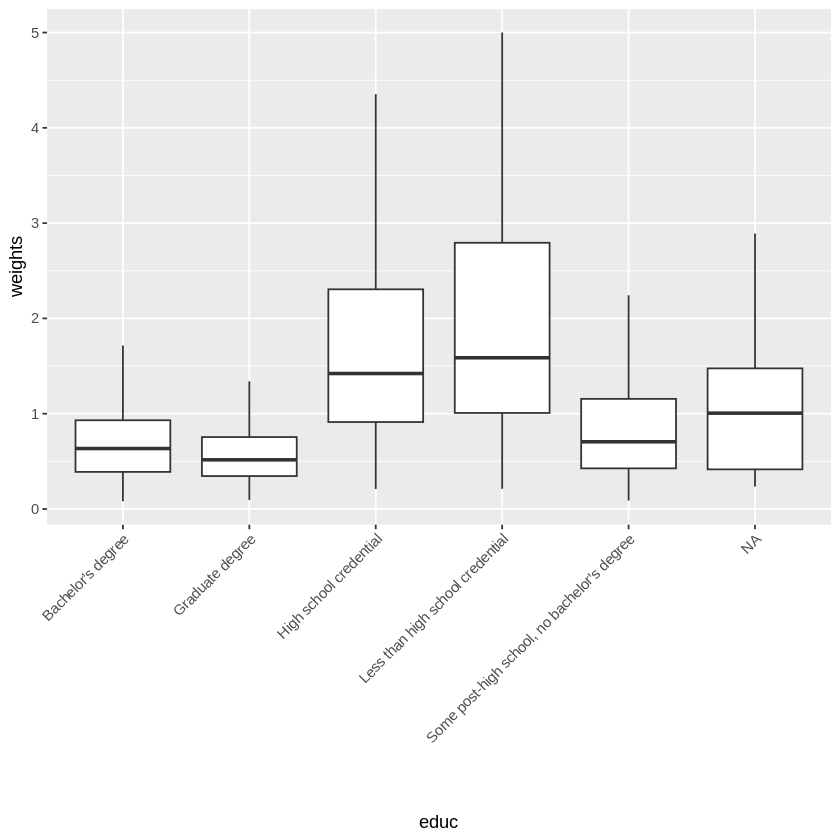

In [10]:
ggplot(anes) +
  geom_boxplot(aes(x = educ, y = weights), outliers = FALSE) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

## Topline Results

Using just the tidyverse, we can generate both the unweighted and weighted presidential vote. To make this easier, let's introduce a new function: `count()`.

In [11]:
anes |>
  filter(!is.na(pres_vote)) |>
  count(pres_vote)

pres_vote,n
<chr>,<int>
Donald Trump,877
Kamala Harris,1034
Other,133


In [12]:
anes |>
  filter(!is.na(pres_vote)) |>
  count(pres_vote, wt = weights)

pres_vote,n
<chr>,<dbl>
Donald Trump,869.2234
Kamala Harris,1010.4980
Other,132.0782


What if we want proportions instead of counts?

In [13]:
anes |>
  filter(!is.na(pres_vote)) |>
  count(pres_vote, wt = weights) |>
  mutate(prop = n / sum(n))

pres_vote,n,prop
<chr>,<dbl>,<dbl>
Donald Trump,869.2234,0.43206261
Kamala Harris,1010.4980,0.50228561
Other,132.0782,0.06565179


This is known as a "topline" result, because it includes everyone in the sample.

Of course, we know that every time we have a sample, we also have uncertainty about whether our estimate is the same as the true population mean (the true percentage of voters who intended to vote for Harris). This is because for any given sample, we sometimes get an estimate that is in the tails of the sampling distribution, and is much too high or much too low. We account for this uncertainty using the margin of error.

You do not need to memorize the margin of error formula for this class, but you will need this code from time to time. My recommendation is to have it in an easy-to-find location so that you can copy and paste it when you need it. This code generates the margin of error for each response option.

In [14]:
anes |>
  filter(!is.na(pres_vote)) |>
  count(pres_vote, wt = weights) |>
  mutate(
    prop = n / sum(n),
    total = sum(n),
    moe = 1.96 * sqrt((prop * (1 - prop)) / total)
  )

pres_vote,n,prop,total,moe
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Donald Trump,869.2234,0.43206261,2011.8,0.02164648
Kamala Harris,1010.4980,0.50228561,2011.8,0.02184888
Other,132.0782,0.06565179,2011.8,0.01082284


Based on this code, we learn that if we redid this survey 100 times, in 95 of those surveys, the estimated vote for Donald Trump would be between 41.0 - 45.4%, and the estimated vote for Kamala Harris would be between 48.0 - 52.4%.

Because these confidence intervals do not overlap, we can say that Harris is statistically significantly ahead of Trump in this poll. How can we show this visually to our readers who might not be familiar with confidence intervals?

In ggplot2, there is a `geom_*()` layer that puts error bars on our estimates. It is called `geom_errorbar()`, and it works similarly to all of our other `geom_*()` layers. We just need to tell it where to put the bottom and top of the error bars.

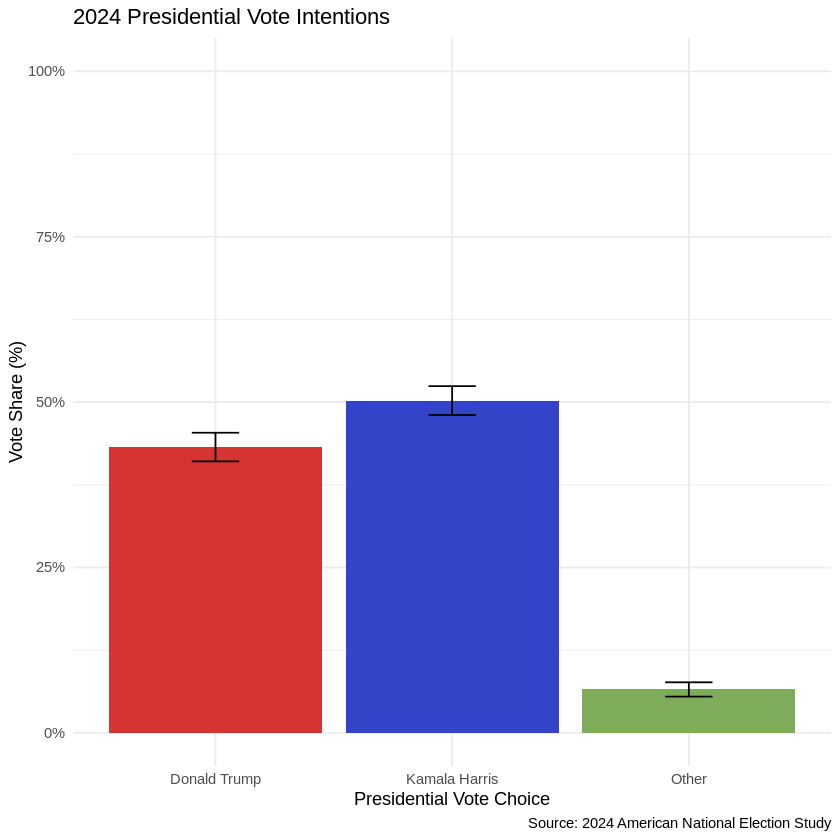

In [15]:
anes |>
  filter(!is.na(pres_vote)) |>
  count(pres_vote, wt = weights) |>
  mutate(
    prop = n / sum(n),
    total = sum(n),
    moe = 1.96 * sqrt((prop * (1 - prop)) / total)
  ) |>
  ggplot() +
  geom_col(aes(x = pres_vote, y = prop, fill = pres_vote)) +
  scale_fill_manual(values = c("#D63333", "#3344C9", "#7EAC5B")) +
  geom_errorbar(
    aes(x = pres_vote, ymin = prop - moe, ymax = prop + moe),
    width = .2
  ) +
  scale_y_continuous(limits = c(0, 1), labels = scales::percent_format()) +
  labs(
    x = "Presidential Vote Choice",
    y = "Vote Share (%)",
    title = "2024 Presidential Vote Intentions",
    caption = "Source: 2024 American National Election Study"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

## Crosstab Results

A "crosstab" is when we compare the results of a poll question across subgroups. For example, what if we want to know how presidential vote varies by age?
Note: a crosstab only works if both variables are categorical (i.e., not continuous). So if we have a continuous variable like age or income, we need to convert it into categories first.

In [16]:
anes_age <-
  anes |>
  mutate(
    agecat = case_when(
      age < 30 ~ "18-29",
      age >= 30 & age < 45 ~ "30-44",
      age >= 45 & age < 60 ~ "45-59",
      age >= 60 ~ "60+",
      TRUE ~ NA
    )
  )

In [17]:
anes_age |>
  filter(!is.na(agecat) & !is.na(pres_vote)) |>
  count(agecat, pres_vote, wt = weights)

agecat,pres_vote,n
<chr>,<chr>,<dbl>
18-29,Donald Trump,53.810926
18-29,Kamala Harris,62.415920
18-29,Other,6.922792
30-44,Donald Trump,250.407818
30-44,Kamala Harris,260.718078
30-44,Other,46.221590
45-59,Donald Trump,227.235867
45-59,Kamala Harris,261.243671
45-59,Other,39.736682


One of the challenges of `count()` is that it does not leave your data frame "grouped", so we need to add another `group_by()` function before calculating our proportions and margins of error.

In [18]:
anes_age |>
  filter(!is.na(agecat) & !is.na(pres_vote)) |>
  count(agecat, pres_vote, wt = weights) |>
  group_by(agecat) |>
  mutate(
    prop = n / sum(n),
    total = sum(n),
    moe = 1.96 * sqrt((prop * (1 - prop)) / total)
  )

agecat,pres_vote,n,prop,total,moe
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
18-29,Donald Trump,53.810926,0.43695562,123.1496,0.08760512
18-29,Kamala Harris,62.415920,0.50682991,123.1496,0.08830168
18-29,Other,6.922792,0.05621447,123.1496,0.04068181
30-44,Donald Trump,250.407818,0.44928492,557.3475,0.04129690
30-44,Kamala Harris,260.718078,0.46778372,557.3475,0.04142473
30-44,Other,46.221590,0.08293137,557.3475,0.02289567
45-59,Donald Trump,227.235867,0.43019479,528.2162,0.04222270
45-59,Kamala Harris,261.243671,0.49457715,528.2162,0.04263779
45-59,Other,39.736682,0.07522806,528.2162,0.02249352


Look at how much larger our margins of error are when we are calculating crosstabs! This is because our sample size is much smaller when we are looking at subgroups of the population. For this reason, we have to be even more cautious when interpreting crosstab results.

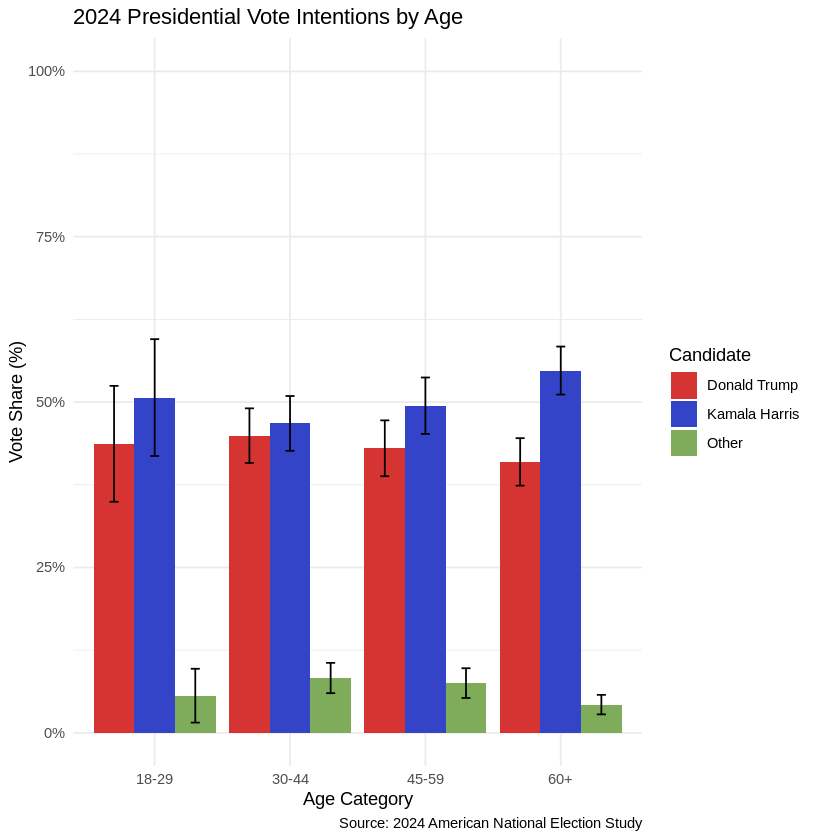

In [19]:
anes_age |>
  filter(!is.na(agecat) & !is.na(pres_vote)) |>
  count(agecat, pres_vote, wt = weights) |>
  group_by(agecat) |>
  mutate(
    prop = n / sum(n),
    total = sum(n),
    moe = 1.96 * sqrt((prop * (1 - prop)) / total)
  ) |>
  ggplot() +
  geom_col(
    aes(x = agecat, y = prop, fill = pres_vote),
    position = position_dodge(.9) # Instead of "dodge" - a quirk of ggplot2
  ) +
  geom_errorbar(
    aes(x = agecat, ymin = prop - moe, ymax = prop + moe, group = pres_vote),
    position = position_dodge(.9), # Instead of "dodge" - a quirk of ggplot2
    width = .2
  ) +
  scale_y_continuous(limits = c(0, 1), labels = scales::percent_format()) +
  scale_fill_manual(values = c("#D63333", "#3344C9", "#7EAC5B")) +
  labs(
    x = "Age Category",
    y = "Vote Share (%)",
    fill = "Candidate",
    title = "2024 Presidential Vote Intentions by Age",
    caption = "Source: 2024 American National Election Study"
  ) +
  theme_minimal()

These results are very interesting! According to this poll, the only group that Harris is winning with statistical certainty is the age 60+ group. All other age groups have overlapping confidence intervals, meaning that we cannot say with certainty that one candidate is ahead of the other. This is contrary to the conventional wisdom that younger voters are more likely to vote for Democrats, and older voters are more likely to vote for Republicans.

You can use this same code to analyze other variables in the dataset. For example, how does presidential vote vary by race? By education? We can also look at other questions in the survey that are not weighting and/or demographic variables, such as how closely someone pays attention to politics.

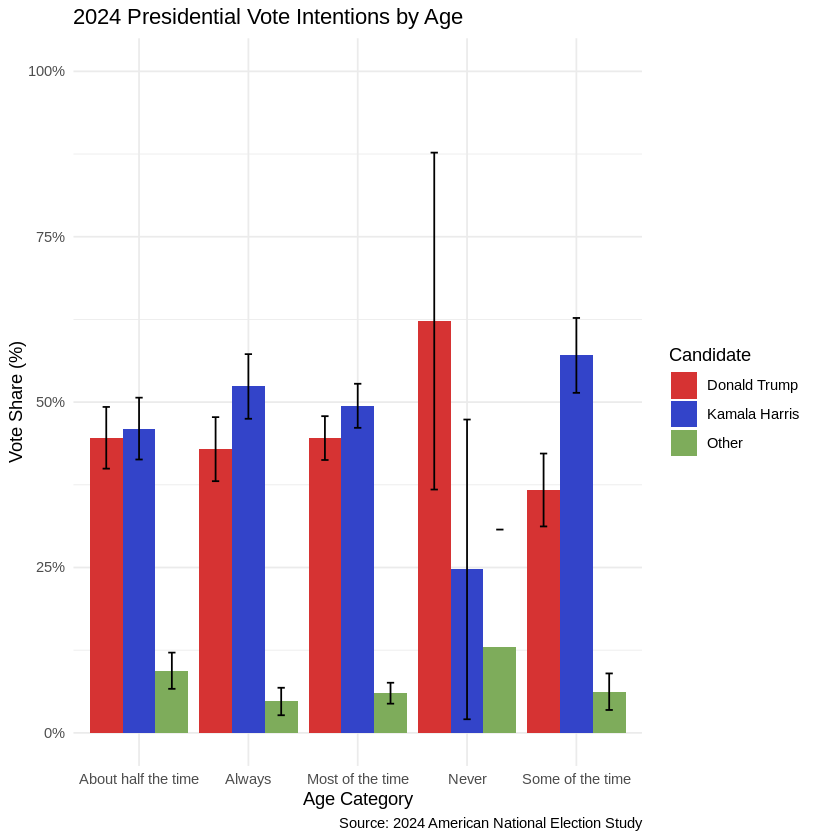

In [20]:
anes |>
  filter(!is.na(attention_to_politics) & !is.na(pres_vote)) |>
  count(attention_to_politics, pres_vote, wt = weights) |>
  group_by(attention_to_politics) |>
  mutate(
    prop = n / sum(n),
    total = sum(n),
    moe = 1.96 * sqrt((prop * (1 - prop)) / total)
  ) |>
  ggplot() +
  geom_col(
    aes(x = attention_to_politics, y = prop, fill = pres_vote),
    position = position_dodge(.9) # Instead of "dodge" - a quirk of ggplot2
  ) +
  geom_errorbar(
    aes(
      x = attention_to_politics,
      ymin = prop - moe,
      ymax = prop + moe,
      group = pres_vote # This is the geom_errorbar equivalent of fill.
    ),
    position = position_dodge(.9), # Instead of "dodge" - a quirk of ggplot2
    width = .2
  ) +
  scale_y_continuous(limits = c(0, 1), labels = scales::percent_format()) +
  scale_fill_manual(values = c("#D63333", "#3344C9", "#7EAC5B")) +
  labs(
    x = "Age Category",
    y = "Vote Share (%)",
    fill = "Candidate",
    title = "2024 Presidential Vote Intentions by Age",
    caption = "Source: 2024 American National Election Study"
  ) +
  theme_minimal()

The order here is a bit odd. We can fix this by reordering the *factor levels* of attention_to_politics. We can do this using the `factor()` function inside `mutate()`, but please be careful: the levels argument has to include all of the values in the variable, and spelled/capitalized exactly the same way!

In [21]:
anes_attention <- anes |>
  mutate(
    attention_to_politics = factor(
      attention_to_politics,
      levels = c(
        "Always",
        "Most of the time",
        "About half the time",
        "Some of the time",
        "Never"
      )
    )
  )

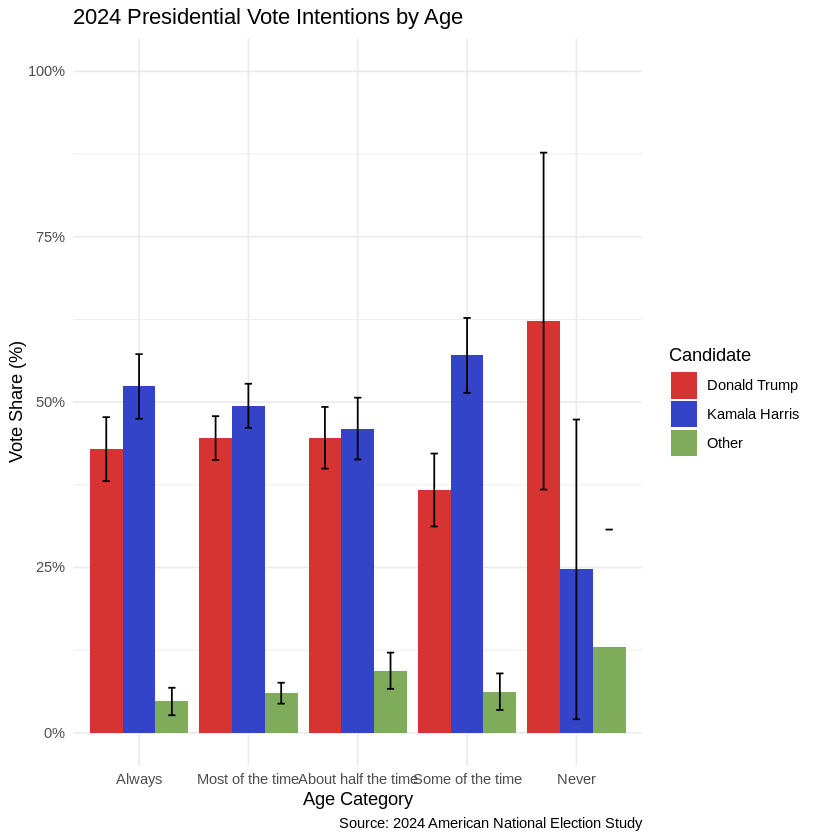

In [22]:
anes_attention |>
  filter(!is.na(attention_to_politics) & !is.na(pres_vote)) |>
  count(attention_to_politics, pres_vote, wt = weights) |>
  group_by(attention_to_politics) |>
  mutate(
    prop = n / sum(n),
    total = sum(n),
    moe = 1.96 * sqrt((prop * (1 - prop)) / total)
  ) |>
  ggplot() +
  geom_col(
    aes(x = attention_to_politics, y = prop, fill = pres_vote),
    position = position_dodge(.9) # Instead of "dodge" - a quirk of ggplot2
  ) +
  geom_errorbar(
    aes(
      x = attention_to_politics,
      ymin = prop - moe,
      ymax = prop + moe,
      group = pres_vote
    ),
    position = position_dodge(.9), # Instead of "dodge" - a quirk of ggplot2
    width = .2
  ) +
  scale_y_continuous(limits = c(0, 1), labels = scales::percent_format()) +
  scale_fill_manual(values = c("#D63333", "#3344C9", "#7EAC5B")) +
  labs(
    x = "Age Category",
    y = "Vote Share (%)",
    fill = "Candidate",
    title = "2024 Presidential Vote Intentions by Age",
    caption = "Source: 2024 American National Election Study"
  ) +
  theme_minimal()

We might be tempted to say that people who never pay attention to politics are more likely to vote for Trump. However, look at the margins of error here! The confidence intervals for both candidates overlap, even though the estimate for Trump is so large. Think about how few people in this group probably answered the survey, so our uncertainty is large.

The point of this exercise is that it is really easy to dive into the crosstabs to find surprising results and build a narrative - but often we are so uncertain about these results that we cannot be sure our results are just chance. It is a fallacy that happens often in media analyses of polling results, so be on the lookout for small samples sizes and large uncertainty before drawing any conclusions of your own from polls.